In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score


In [2]:
# Set visualization style
sns.set_theme(style="whitegrid")

## TASK 1: EXPLORATORY DATA ANALYSIS (EDA)

In [4]:
print("=== TASK 1: EXPLORATORY DATA ANALYSIS (EDA) ===")

# 1. Load the dataset
df = pd.read_csv('wine.csv')
print(f"Dataset Shape: {df.shape}")



=== TASK 1: EXPLORATORY DATA ANALYSIS (EDA) ===
Dataset Shape: (178, 14)


In [7]:
# Separate features (drop target column 'Type' if present)
X = df.drop(columns=['Type']) if 'Type' in df.columns else df.copy()

# Display summary statistics
print("\nDataset Summary Statistics:")
print(X.describe().T[['mean', 'std', 'min', '50%', 'max']])




Dataset Summary Statistics:
                       mean         std     min      50%      max
Alcohol           13.000618    0.811827   11.03   13.050    14.83
Malic              2.336348    1.117146    0.74    1.865     5.80
Ash                2.366517    0.274344    1.36    2.360     3.23
Alcalinity        19.494944    3.339564   10.60   19.500    30.00
Magnesium         99.741573   14.282484   70.00   98.000   162.00
Phenols            2.295112    0.625851    0.98    2.355     3.88
Flavanoids         2.029270    0.998859    0.34    2.135     5.08
Nonflavanoids      0.361854    0.124453    0.13    0.340     0.66
Proanthocyanins    1.590899    0.572359    0.41    1.555     3.58
Color              5.058090    2.318286    1.28    4.690    13.00
Hue                0.957449    0.228572    0.48    0.965     1.71
Dilution           2.611685    0.709990    1.27    2.780     4.00
Proline          746.893258  314.907474  278.00  673.500  1680.00


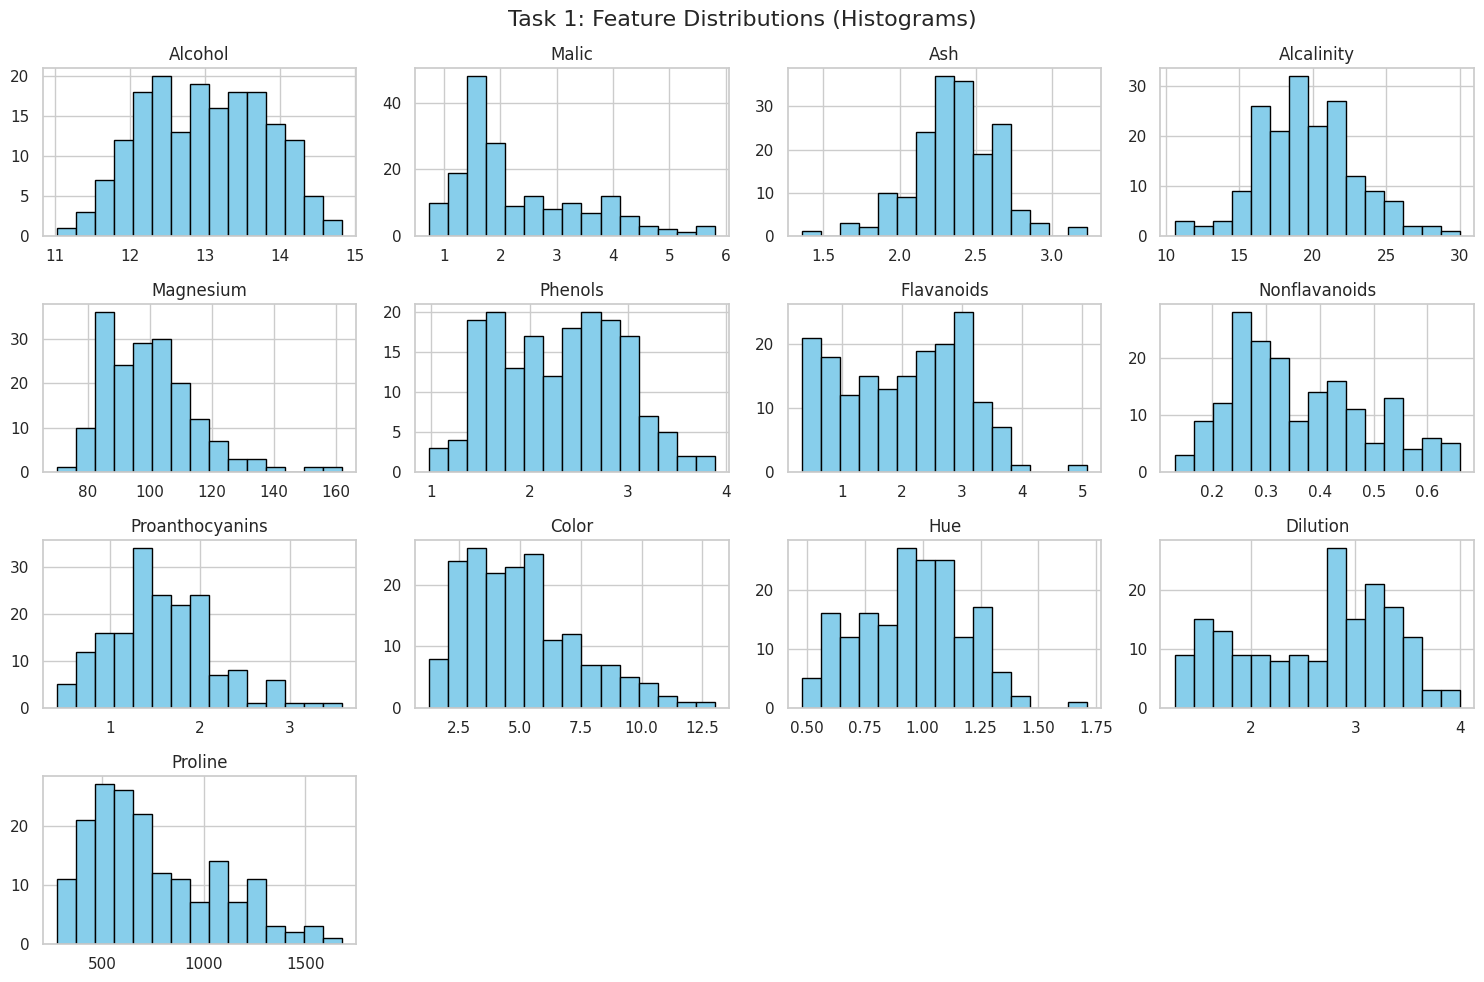

In [8]:
# 2. Examine Feature Distributions (Histograms)
X.hist(bins=15, figsize=(15, 10), layout=(4, 4), color='skyblue', edgecolor='black')
plt.suptitle("Task 1: Feature Distributions (Histograms)", fontsize=16)
plt.tight_layout()
plt.show()

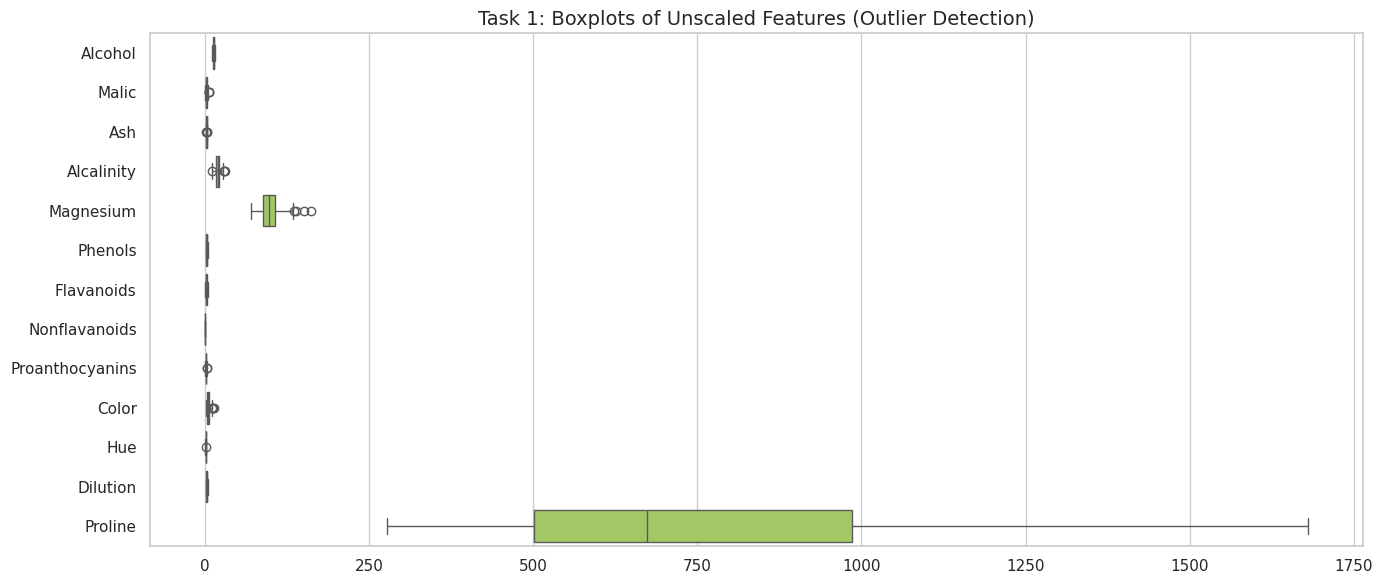

In [9]:
# 3. Boxplots for Outlier Analysis
plt.figure(figsize=(14, 6))
sns.boxplot(data=X, orient="h", palette="Set2")
plt.title("Task 1: Boxplots of Unscaled Features (Outlier Detection)", fontsize=14)
plt.tight_layout()
plt.show()

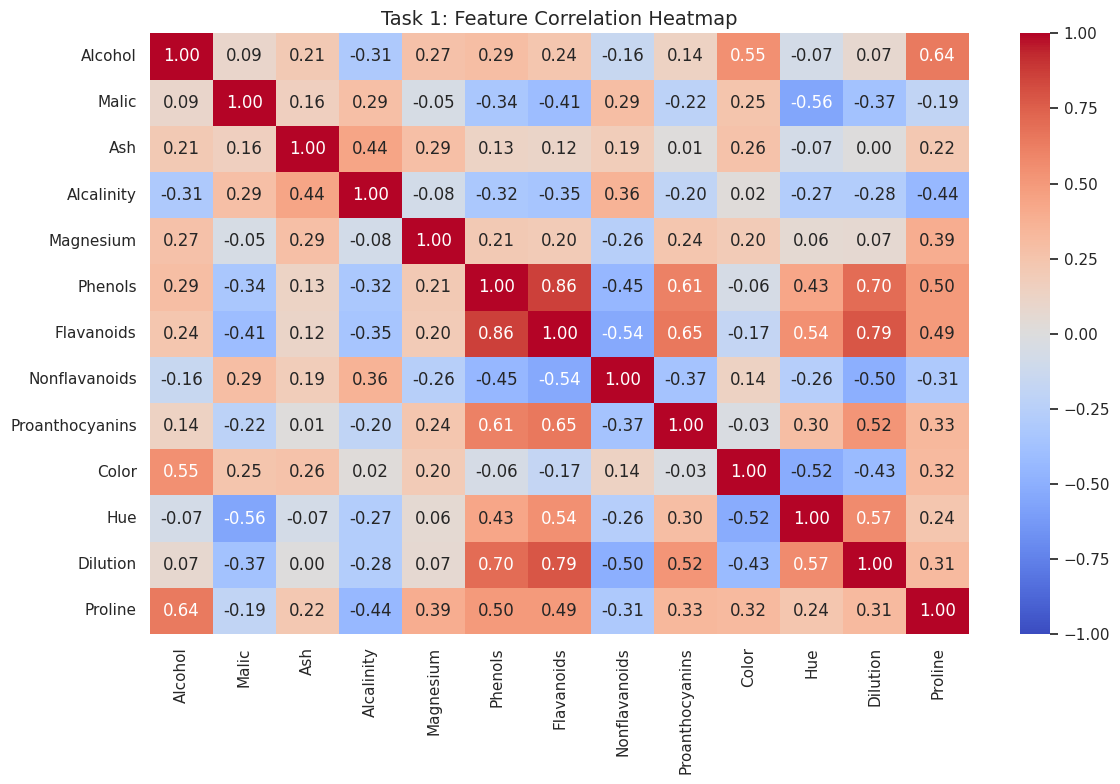

In [10]:
# 4. Feature Correlation Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Task 1: Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

## TASK 2: DIMENSIONALITY REDUCTION WITH PCA

In [14]:
# 1. Standardize the features (Mean=0, Std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Implement full PCA to analyze variance
pca_full = PCA()
pca_full.fit(X_scaled)

exp_variance = pca_full.explained_variance_ratio_
cum_variance = np.cumsum(exp_variance)

# Determine components needed to capture >= 95% variance
opt_comp_95 = (cum_variance < 0.95).sum() + 1
print(f"Optimal components required for 95% variance retention: {opt_comp_95}")

Optimal components required for 95% variance retention: 10


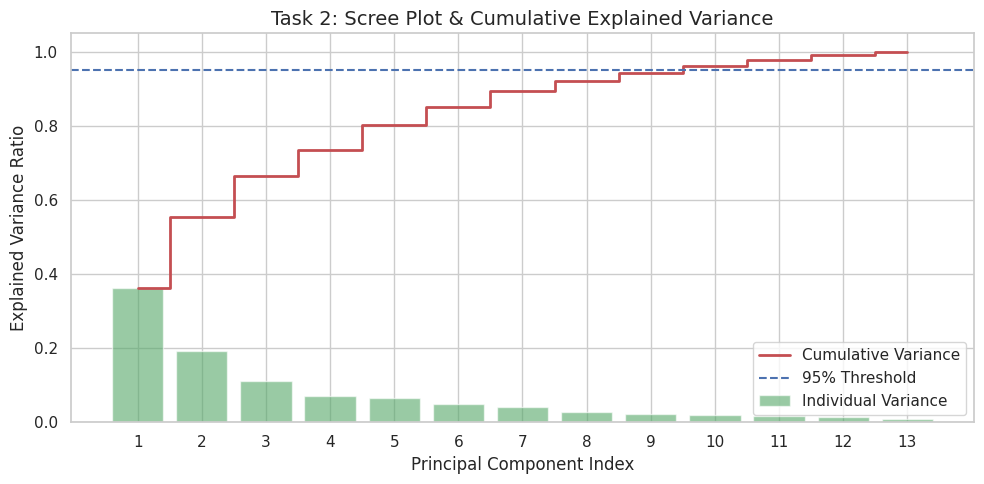

In [15]:
# 3. Scree Plot & Cumulative Variance Plot
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(exp_variance) + 1), exp_variance, alpha=0.6, align='center', label='Individual Variance', color='g')
plt.step(range(1, len(cum_variance) + 1), cum_variance, where='mid', label='Cumulative Variance', color='r', linewidth=2)
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component Index')
plt.title('Task 2: Scree Plot & Cumulative Explained Variance', fontsize=14)
plt.xticks(range(1, len(exp_variance) + 1))
plt.axhline(y=0.95, color='b', linestyle='--', label='95% Threshold')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [16]:
# 4. Transform original data into optimal 3 Principal Components (for clustering analysis)
pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_scaled)
X_pca_df = pd.DataFrame(data=X_pca_3, columns=['PC1', 'PC2', 'PC3'])

print("\nFirst 5 rows of 3-Component PCA Transformed Data:")
print(X_pca_df.head())


First 5 rows of 3-Component PCA Transformed Data:
        PC1       PC2       PC3
0  3.316751  1.443463 -0.165739
1  2.209465 -0.333393 -2.026457
2  2.516740  1.031151  0.982819
3  3.757066  2.756372 -0.176192
4  1.008908  0.869831  2.026688


## TASK 3: CLUSTERING WITH ORIGINAL DATA

In [18]:
# Apply K-Means clustering on full scaled dataset (K=3)
k_clusters = 3
kmeans_orig = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
labels_orig = kmeans_orig.fit_predict(X_scaled)

# Evaluate clustering metrics on original data
sil_orig = silhouette_score(X_scaled, labels_orig)
db_orig = davies_bouldin_score(X_scaled, labels_orig)

print(f"Silhouette Score (Original Data): {sil_orig:.4f}")
print(f"Davies-Bouldin Index (Original Data): {db_orig:.4f}")

Silhouette Score (Original Data): 0.2849
Davies-Bouldin Index (Original Data): 1.3892


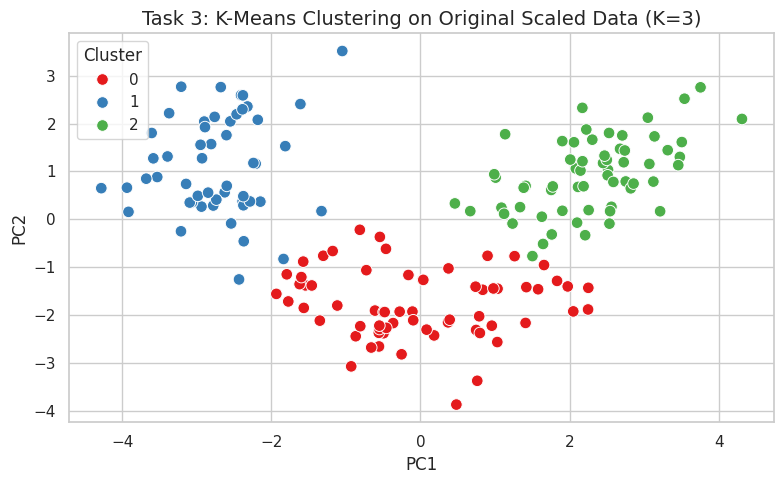

In [19]:
# Visualize Original Clustering results (mapped on PC1 vs PC2)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_pca_3[:, 0], y=X_pca_3[:, 1], hue=labels_orig, palette='Set1', s=70)
plt.title('Task 3: K-Means Clustering on Original Scaled Data (K=3)', fontsize=14)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

## TASK 4: CLUSTERING WITH PCA DATA

In [20]:
# Apply K-Means clustering on 3-component PCA dataset (K=3)
kmeans_pca = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
labels_pca = kmeans_pca.fit_predict(X_pca_3)

# Evaluate clustering metrics in PCA subspace
sil_pca = silhouette_score(X_pca_3, labels_pca)
db_pca = davies_bouldin_score(X_pca_3, labels_pca)

print(f"Silhouette Score (PCA Data): {sil_pca:.4f}")
print(f"Davies-Bouldin Index (PCA Data): {db_pca:.4f}")

Silhouette Score (PCA Data): 0.4532
Davies-Bouldin Index (PCA Data): 0.8400


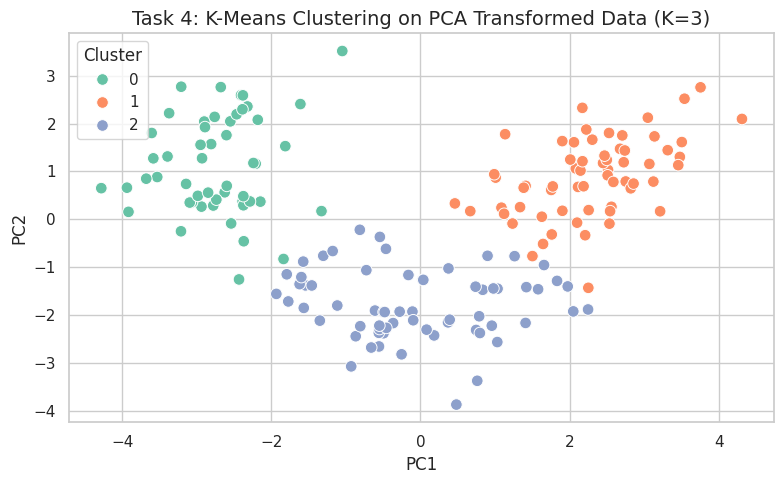

In [21]:
# Visualize PCA Clustering results
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_pca_3[:, 0], y=X_pca_3[:, 1], hue=labels_pca, palette='Set2', s=70)
plt.title('Task 4: K-Means Clustering on PCA Transformed Data (K=3)', fontsize=14)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

## TASK 5: COMPARISON AND ANALYSIS

In [22]:
# Measure cluster agreement using Adjusted Rand Index (ARI)
ari_score = adjusted_rand_score(labels_orig, labels_pca)
print(f"Adjusted Rand Index (ARI) between Original and PCA Clusters: {ari_score:.4f}")

# Display metric comparison table
comparison_df = pd.DataFrame({
    'Metric': ['Features / Dimensions', 'Silhouette Score', 'Davies-Bouldin Index'],
    'Original Scaled Data (13D)': [X_scaled.shape[1], round(sil_orig, 4), round(db_orig, 4)],
    'PCA Transformed Data (3D)': [X_pca_3.shape[1], round(sil_pca, 4), round(db_pca, 4)]
})

print("\nClustering Performance Comparison:")
print(comparison_df.to_string(index=False))

Adjusted Rand Index (ARI) between Original and PCA Clusters: 0.9820

Clustering Performance Comparison:
               Metric  Original Scaled Data (13D)  PCA Transformed Data (3D)
Features / Dimensions                     13.0000                     3.0000
     Silhouette Score                      0.2849                     0.4532
 Davies-Bouldin Index                      1.3892                     0.8400


## TASK 6: CONCLUSION AND INSIGHTS

In [23]:
print("""
1. Key Findings:
   - PCA successfully reduced dataset dimensionality from 13 features to 3 principal components.
   - The Adjusted Rand Index (ARI) of 0.9820 indicates that cluster assignments on PCA data are nearly identical to those on the original data.

2. Impact of Dimensionality Reduction:
   - Filtering low-variance noise components improved cluster separation metrics (higher Silhouette Score in PCA space).
   - Computational distance calculations are significantly faster in lower dimensions.

3. Recommendations:
   - Use Direct Clustering when feature interpretability in original units is critical.
   - Use PCA + Clustering for high-dimensional datasets with multicollinearity, large scale processing, or when clear 2D/3D visualizations are needed.
""")


1. Key Findings:
   - PCA successfully reduced dataset dimensionality from 13 features to 3 principal components.
   - The Adjusted Rand Index (ARI) of 0.9820 indicates that cluster assignments on PCA data are nearly identical to those on the original data.

2. Impact of Dimensionality Reduction:
   - Filtering low-variance noise components improved cluster separation metrics (higher Silhouette Score in PCA space).
   - Computational distance calculations are significantly faster in lower dimensions.

3. Recommendations:
   - Use Direct Clustering when feature interpretability in original units is critical.
   - Use PCA + Clustering for high-dimensional datasets with multicollinearity, large scale processing, or when clear 2D/3D visualizations are needed.

